1. Define the question

In [11]:
import pandas as pd
import seaborn as sns
df = sns.load_dataset('titanic')

# Basic inspection
print(df.info())               # Data types and null values
print(df.describe())           # Summary statistics
print(df.head())               # Preview of the data
print(df.isnull().sum())       # Check missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
         survived      pclass         age       sibsp       parch        f

What do you want to ask?

Q1)
Q2)
Q3)
...




2. EDA

Univariate (only one feature)

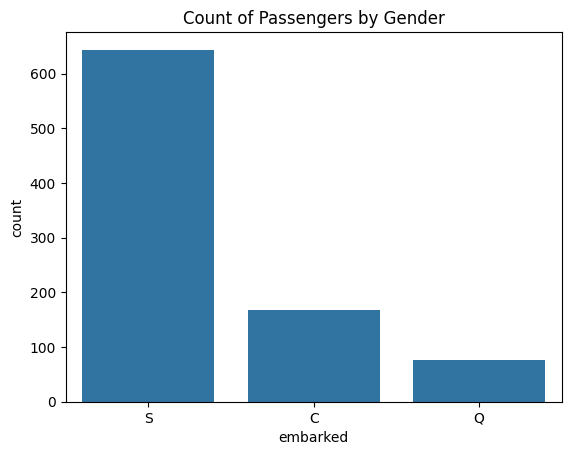

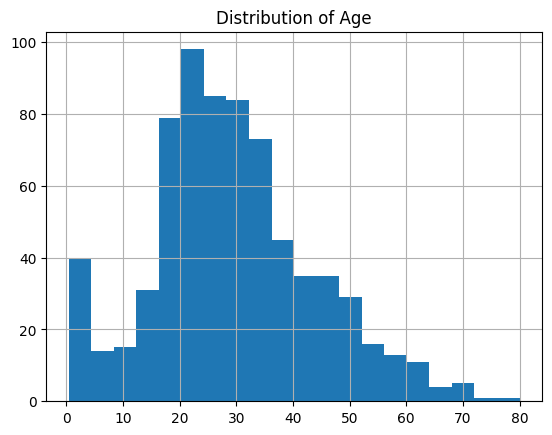

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count plot for categorical variables
sns.countplot(x='embarked', data=df)
plt.title('Count of Passengers by Gender')
plt.show()

# Histogram for numerical variables
df['age'].hist(bins=20)
plt.title('Distribution of Age')
plt.show()


Bivariate (2 features)

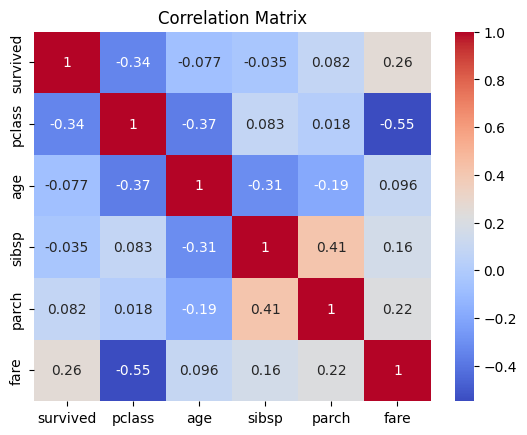

In [13]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Heatmap of correlations
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


Multivariate

class      First    Second     Third
sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447


C:\Users\k.key B\AppData\Local\Temp\ipykernel_15544\2039217329.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  print(pd.pivot_table(df, values='survived', index='sex', columns='class'))


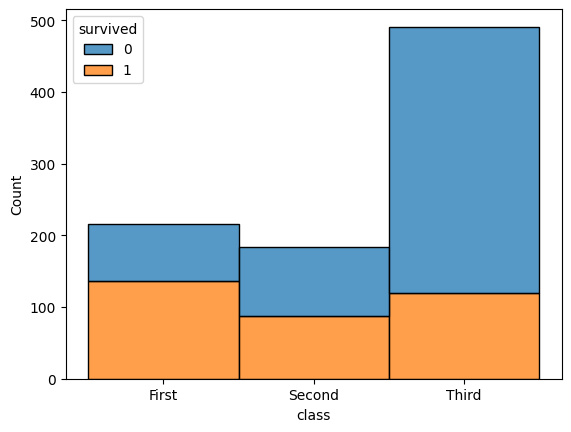

In [14]:
df['survived'] = df['survived'].astype(int)

# Pivot table for survival rate by gender and class
print(pd.pivot_table(df, values='survived', index='sex', columns='class'))

# Stacked bar chart for survival rate by gender and class
sns.histplot(data=df, x='class', hue='survived', multiple='stack')
plt.show()


3. Data Cleaning

In [15]:
# Fill missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Drop 'deck' column due to high percentage of missing values, and drop those seems duplicated columns
df.drop(columns=['pclass', 'deck', 'who', 'adult_male', 'embark_town', 'alive', 'alone'], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)


C:\Users\k.key B\AppData\Local\Temp\ipykernel_15544\2834190742.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\k.key B\AppData\Local\Temp\ipykernel_15544\2834190742.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

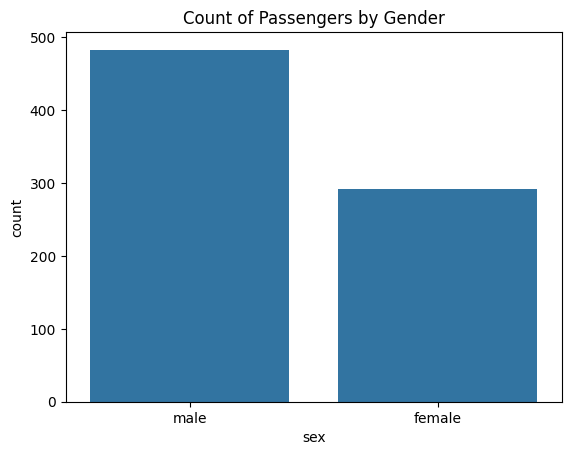

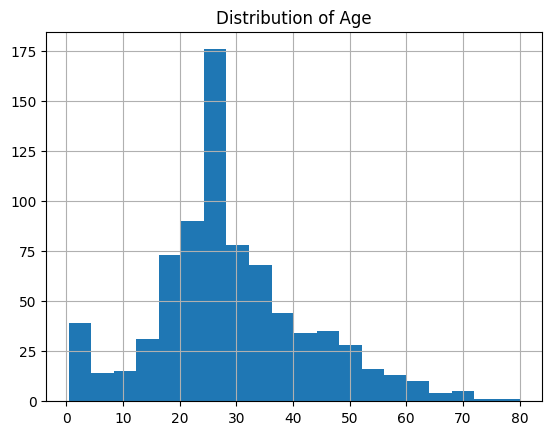

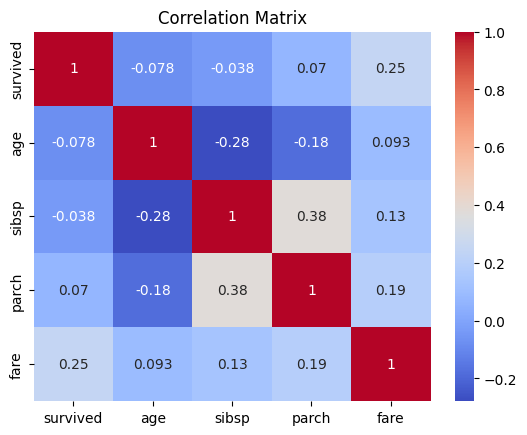

class      First    Second     Third
sex                                 
female  0.967742  0.916667  0.472441
male    0.367521  0.184783  0.160584


C:\Users\k.key B\AppData\Local\Temp\ipykernel_15544\2372393070.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  print(pd.pivot_table(df, values='survived', index='sex', columns='class'))


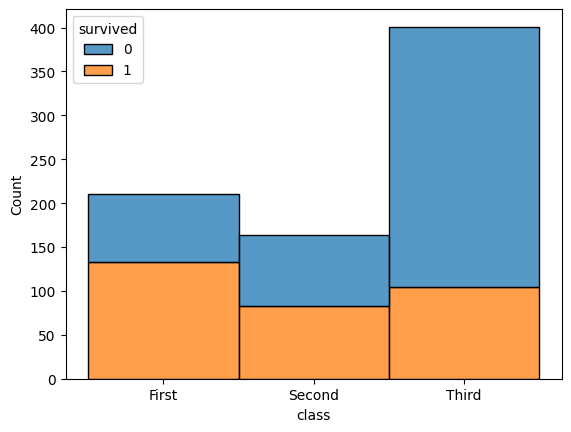

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count plot for categorical variables
sns.countplot(x='sex', data=df)
plt.title('Count of Passengers by Gender')
plt.show()

# Histogram for numerical variables
df['age'].hist(bins=20)
plt.title('Distribution of Age')
plt.show()

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Heatmap of correlations
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Pivot table for survival rate by gender and class
print(pd.pivot_table(df, values='survived', index='sex', columns='class'))

# Stacked bar chart for survival rate by gender and class
sns.histplot(data=df, x='class', hue='survived', multiple='stack')
plt.show()



4. Feature Engineering

In [17]:
# Age groups
df['AgeGroup'] = pd.cut(df['age'], bins=[0, 12, 20, 40, 60, 80], labels=['Child', 'Teen', 'Adult', 'Middle Age', 'Senior'])

# Fare bins
df['FareGroup'] = pd.qcut(df['fare'], 3, labels=['Low', 'Medium', 'High'])

# Family size
df['FamilySize'] = df['sibsp'] + df['parch']

# Is alone feature
df['IsAlone'] = (df['FamilySize'] == 0).astype(int)


You can plot the graph and see what's the distribution for these new features.

5. Encoding Categorial variables

In [18]:
# Encode categorical variables
df = pd.get_dummies(df, columns=['sex', 'embarked', 'class', 'AgeGroup', 'FareGroup'], drop_first=True)


In [19]:
df.head(10)

,survived,age,sibsp,parch,fare,FamilySize,IsAlone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Middle Age,AgeGroup_Senior,FareGroup_Medium,FareGroup_High
0,0,22.0,1,0,7.2500,1,0,True,False,True,False,True,False,True,False,False,False,False
1,1,38.0,1,0,71.2833,1,0,False,False,False,False,False,False,True,False,False,False,True
2,1,26.0,0,0,7.9250,0,1,False,False,True,False,True,False,True,False,False,False,False
3,1,35.0,1,0,53.1000,1,0,False,False,True,False,False,False,True,False,False,False,True
4,0,35.0,0,0,8.0500,0,1,True,False,True,False,True,False,True,False,False,False,False
5,0,28.0,0,0,8.4583,0,1,True,True,False,False,True,False,True,False,False,False,False
6,0,54.0,0,0,51.8625,0,1,True,False,True,False,False,False,False,True,False,False,True
7,0,2.0,3,1,21.0750,4,0,True,False,True,False,True,False,False,False,False,True,False
8,1,27.0,0,2,11.1333,2,0,False,False,True,False,True,False,True,False,False,True,False
9,1,14.0,1,0,30.0708,1,0,False,False,False,True,False,True,False,False,False,False,True


5. Data Transformation and Scaling (yes still under step 5)

In [20]:
from sklearn.preprocessing import StandardScaler

# Standardize Age and Fare columns
scaler = StandardScaler()
df[['age', 'fare']] = scaler.fit_transform(df[['age', 'fare']])

df.head(10)

ModuleNotFoundError: No module named 'sklearn'

7. Predictive Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Define features and target
X = df.drop(['survived'], axis=1)
y = df['survived']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]


8. Model Evaluation

In [ ]:
# Accuracy, Classification Report, and Confusion Matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8076923076923077
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84        91
           1       0.79      0.74      0.76        65

    accuracy                           0.81       156
   macro avg       0.80      0.80      0.80       156
weighted avg       0.81      0.81      0.81       156

Confusion Matrix:
 [[78 13]
 [17 48]]


ROC-AUC Score: 0.8245139475908707


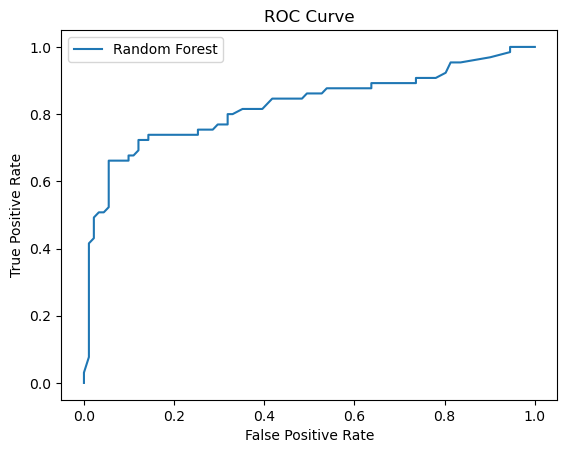

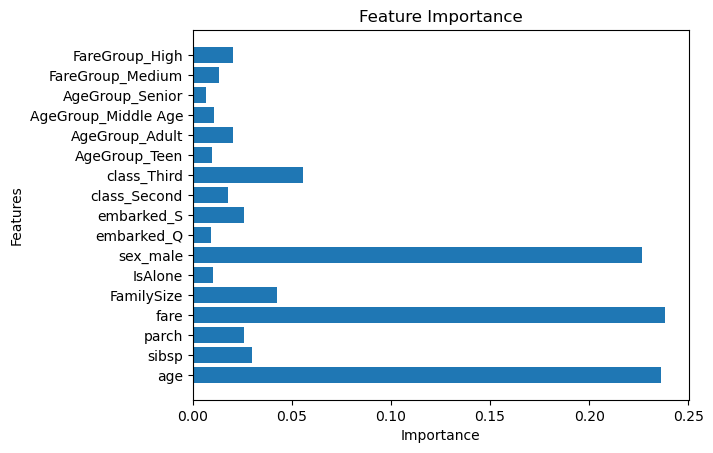

In [ ]:
# ROC-AUC Score
roc_score = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", roc_score)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label='Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Feature importance
importances = model.feature_importances_
features = X.columns
plt.barh(features, importances)
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()
